# Bank Application Fraud Analysis

This project explores one million anonymized bank-account applications to
understand the factors associated with application fraud.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Base.csv")

In [3]:
df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


In [4]:
df.head().T

,0,1,2,3,4
fraud_bool,0,0,0,0,0
income,0.3,0.8,0.8,0.6,0.9
name_email_similarity,0.986506,0.617426,0.996707,0.4751,0.842307
prev_address_months_count,-1,-1,9,11,-1
current_address_months_count,25,89,14,14,29
customer_age,40,20,40,30,40
days_since_request,0.006735,0.010095,0.012316,0.006991,5.742626
intended_balcon_amount,102.453711,-0.849551,-1.490386,-1.863101,47.152498
payment_type,AA,AD,AB,AB,AA
zip_count_4w,1059,1658,1095,3483,2339


In [5]:
df.shape

(1000000, 32)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  str    
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000000 non-nul

In [7]:
df.describe()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,...,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.0,1000000.000000
mean,0.011029,0.562696,0.493694,16.718568,86.587867,33.689080,1.025705e+00,8.661499,1572.692049,5665.296605,...,0.889676,10.839303,0.222988,515.851010,0.025242,7.544940,0.576947,1.018312,0.0,3.288674
std,0.104438,0.290343,0.289125,44.046230,88.406599,12.025799,5.381835e+00,20.236155,1005.374565,3009.380665,...,0.313293,12.116875,0.416251,487.559902,0.156859,8.033106,0.494044,0.180761,0.0,2.209994
min,0.000000,0.100000,0.000001,-1.000000,-1.000000,10.000000,4.036860e-09,-15.530555,1.000000,-170.603072,...,0.000000,-1.000000,0.000000,190.000000,0.000000,-1.000000,0.000000,-1.000000,0.0,0.000000
25%,0.000000,0.300000,0.225216,-1.000000,19.000000,20.000000,7.193246e-03,-1.181488,894.000000,3436.365848,...,1.000000,-1.000000,0.000000,200.000000,0.000000,3.103053,0.000000,1.000000,0.0,1.000000
50%,0.000000,0.600000,0.492153,-1.000000,52.000000,30.000000,1.517574e-02,-0.830507,1263.000000,5319.769349,...,1.000000,5.000000,0.000000,200.000000,0.000000,5.114321,1.000000,1.000000,0.0,3.000000
75%,0.000000,0.800000,0.755567,12.000000,130.000000,40.000000,2.633069e-02,4.984176,1944.000000,7680.717827,...,1.000000,25.000000,0.000000,500.000000,0.000000,8.866131,1.000000,1.000000,0.0,5.000000
max,1.000000,0.900000,0.999999,383.000000,428.000000,90.000000,7.845690e+01,112.956928,6700.000000,16715.565404,...,1.000000,32.000000,1.000000,2100.000000,1.000000,85.899143,1.000000,2.000000,0.0,7.000000


In [8]:
df.columns.tolist()

['fraud_bool',
 'income',
 'name_email_similarity',
 'prev_address_months_count',
 'current_address_months_count',
 'customer_age',
 'days_since_request',
 'intended_balcon_amount',
 'payment_type',
 'zip_count_4w',
 'velocity_6h',
 'velocity_24h',
 'velocity_4w',
 'bank_branch_count_8w',
 'date_of_birth_distinct_emails_4w',
 'employment_status',
 'credit_risk_score',
 'email_is_free',
 'housing_status',
 'phone_home_valid',
 'phone_mobile_valid',
 'bank_months_count',
 'has_other_cards',
 'proposed_credit_limit',
 'foreign_request',
 'source',
 'session_length_in_minutes',
 'device_os',
 'keep_alive_session',
 'device_distinct_emails_8w',
 'device_fraud_count',
 'month']

In [9]:
df["fraud_bool"].value_counts()

fraud_bool
0    988971
1     11029
Name: count, dtype: int64

In [10]:
df["fraud_bool"].value_counts(normalize=True) * 100

fraud_bool
0    98.8971
1     1.1029
Name: proportion, dtype: float64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
negative_one_counts = (df.select_dtypes(include="number") == -1).sum()

negative_one_counts[negative_one_counts > 0]

prev_address_months_count       712920
current_address_months_count      4254
credit_risk_score                  488
bank_months_count               253635
session_length_in_minutes         2015
device_distinct_emails_8w          359
dtype: int64

In [13]:
clean_df = df.copy()

In [14]:
missing_columns = ["prev_address_months_count","current_address_months_count","bank_months_count","session_length_in_minutes","device_distinct_emails_8w"]

In [15]:
clean_df[missing_columns] = clean_df[missing_columns].replace(-1, np.nan)

In [16]:
missing_summary = clean_df.isna().sum().to_frame(name="missing_count")

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(clean_df) * 100
)

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values("missing_percentage", ascending=False)

missing_summary

,missing_count,missing_percentage
prev_address_months_count,712920,71.2920
bank_months_count,253635,25.3635
current_address_months_count,4254,0.4254
session_length_in_minutes,2015,0.2015
device_distinct_emails_8w,359,0.0359


### Missing Values

Special `-1` values were converted to `NaN` in five columns.  
`prev_address_months_count` had the highest missing percentage at 71.29%,
followed by `bank_months_count` at 25.36%. The remaining columns had less
than 0.5% missing values.

Rows were not removed because this would result in substantial data loss.
Missing values will be handled during machine-learning preprocessing.

In [17]:
clean_df[missing_columns].isna().sum()

prev_address_months_count       712920
current_address_months_count      4254
bank_months_count               253635
session_length_in_minutes         2015
device_distinct_emails_8w          359
dtype: int64

In [18]:
categorical_columns = ["payment_type","employment_status","housing_status","source","device_os"]

In [19]:
for column in categorical_columns:
    print(f"\n{column}")
    print(clean_df[column].value_counts(dropna=False))


payment_type
payment_type
AB    370554
AA    258249
AC    252071
AD    118837
AE       289
Name: count, dtype: int64

employment_status
employment_status
CA    730252
CB    138288
CF     44034
CC     37758
CD     26522
CE     22693
CG       453
Name: count, dtype: int64

housing_status
housing_status
BC    372143
BB    260965
BA    169675
BE    169135
BD     26161
BF      1669
BG       252
Name: count, dtype: int64

source
source
INTERNET    992952
TELEAPP       7048
Name: count, dtype: int64

device_os
device_os
other        342728
linux        332712
windows      263506
macintosh     53826
x11            7228
Name: count, dtype: int64


In [20]:
binary_columns = ["fraud_bool","email_is_free","phone_home_valid","phone_mobile_valid","has_other_cards","foreign_request","keep_alive_session","device_fraud_count"]

In [21]:
for column in binary_columns:
    print(column, clean_df[column].unique())

fraud_bool [0 1]
email_is_free [1 0]
phone_home_valid [0 1]
phone_mobile_valid [1 0]
has_other_cards [0 1]
foreign_request [0 1]
keep_alive_session [1 0]
device_fraud_count [0]


In [22]:
constant_columns = clean_df.columns[
    clean_df.nunique(dropna=False) == 1
].tolist()
constant_columns

['device_fraud_count']

In [23]:
clean_df.drop(columns=["device_fraud_count"], inplace=True)

In [24]:
clean_df.shape

(1000000, 31)

# Exploratory Data Analysis

## Target Variable Distribution

In [25]:
fraud_distribution = (
    clean_df["fraud_bool"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)
fraud_distribution

fraud_bool
0    98.8971
1     1.1029
Name: proportion, dtype: float64

### Constant Column

`device_fraud_count` was removed because every record contained the value 0.  
The column had no variation and could not contribute to the analysis or model.

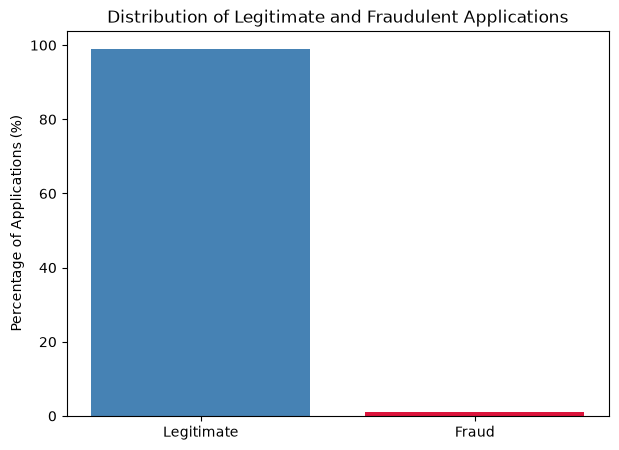

In [26]:
plt.figure(figsize=(7, 5))

plt.bar(["Legitimate", "Fraud"],
    fraud_distribution.values,
    color=["steelblue", "crimson"]
)

plt.title("Distribution of Legitimate and Fraudulent Applications")
plt.ylabel("Percentage of Applications (%)")

plt.show()

## Fraud Trend by Dataset Period

In [27]:
monthly_fraud = (clean_df.groupby("month")["fraud_bool"].agg(
        total_applications="count",
        fraud_cases="sum",
        fraud_rate="mean"
    )
    .reset_index()
)

monthly_fraud["fraud_rate_pct"] = monthly_fraud["fraud_rate"] * 100

monthly_fraud

,month,total_applications,fraud_cases,fraud_rate,fraud_rate_pct
0,0,132440,1500,0.011326,1.132588
1,1,127620,1198,0.009387,0.938724
2,2,136979,1198,0.008746,0.874587
3,3,150936,1392,0.009222,0.922245
4,4,127691,1452,0.011371,1.137120
5,5,119323,1411,0.011825,1.182505
6,6,108168,1450,0.013405,1.340507
7,7,96843,1428,0.014746,1.474552


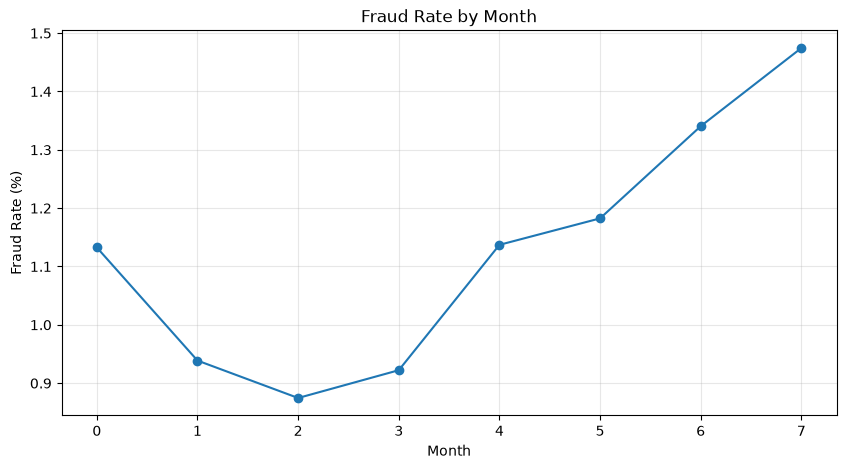

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_fraud["month"],
    monthly_fraud["fraud_rate_pct"],
    marker="o"
)

plt.title("Fraud Rate by Month")
plt.xlabel("Month")
plt.ylabel("Fraud Rate (%)")
plt.grid(alpha=0.3)

plt.show()

## Fraud Analysis by Payment Type

In [29]:
payment_fraud = (
    clean_df.groupby("payment_type")["fraud_bool"]
    .agg(
        total_applications="count",
        fraud_cases="sum",
        fraud_rate="mean"
    )
    .reset_index()
)

In [30]:
payment_fraud["fraud_rate_pct"] = (
    payment_fraud["fraud_rate"] * 100
)

payment_fraud = payment_fraud.sort_values(
    "fraud_rate_pct",
    ascending=False
)

payment_fraud

,payment_type,total_applications,fraud_cases,fraud_rate,fraud_rate_pct
2,AC,252071,4209,0.016698,1.669768
1,AB,370554,4169,0.011251,1.125072
3,AD,118837,1286,0.010822,1.082155
0,AA,258249,1364,0.005282,0.528172
4,AE,289,1,0.003460,0.346021


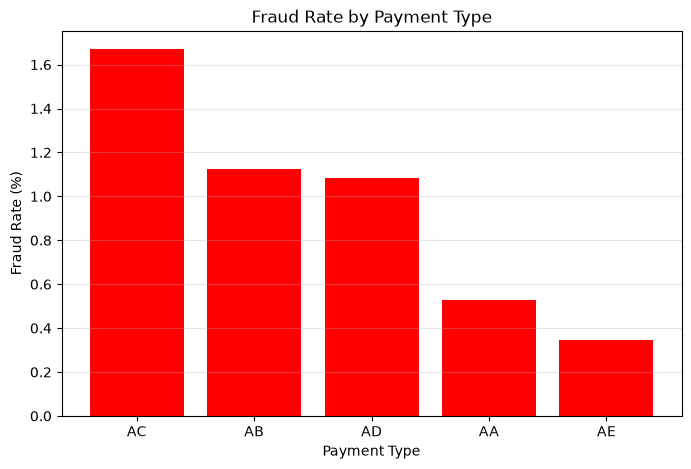

In [31]:
plt.figure(figsize=(8, 5))

plt.bar(
    payment_fraud["payment_type"],
    payment_fraud["fraud_rate_pct"],
    color="Red"
)

plt.title("Fraud Rate by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Fraud Rate (%)")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Finding

Payment type AC recorded the highest fraud rate at approximately 1.67%,
followed by AB and AD. Payment type AA showed a substantially lower fraud
rate of approximately 0.53%.

Although AE recorded the lowest rate, it contained only 289 applications.
Therefore, its result should be interpreted cautiously because of the small
sample size. Payment-type codes are anonymized, so their real-world payment
methods cannot be identified from this dataset.

## Fraud Analysis by Employment Status

In [32]:
employment_fraud = (
    clean_df.groupby("employment_status")["fraud_bool"]
    .agg(
        total_applications="count",
        fraud_cases="sum",
        fraud_rate="mean"
    )
    .reset_index()
)

In [33]:
employment_fraud["fraud_rate_pct"] = (
    employment_fraud["fraud_rate"] * 100
)

employment_fraud = employment_fraud.sort_values(
    "fraud_rate_pct",
    ascending=False
)

employment_fraud

,employment_status,total_applications,fraud_cases,fraud_rate,fraud_rate_pct
2,CC,37758,932,0.024684,2.468351
6,CG,453,7,0.015453,1.545254
0,CA,730252,8899,0.012186,1.218620
1,CB,138288,953,0.006891,0.689142
3,CD,26522,100,0.003770,0.377045
4,CE,22693,53,0.002336,0.233552
5,CF,44034,85,0.001930,0.193033


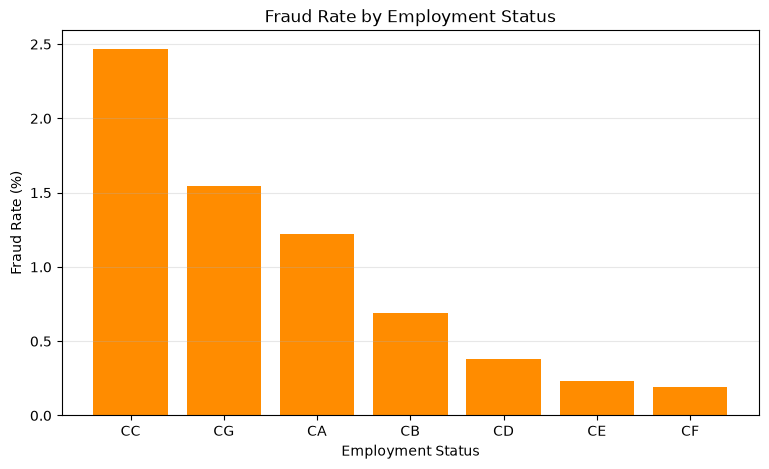

In [34]:
plt.figure(figsize=(9, 5))

plt.bar(
    employment_fraud["employment_status"],
    employment_fraud["fraud_rate_pct"],
    color="darkorange"
)

plt.title("Fraud Rate by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Fraud Rate (%)")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Finding

Employment-status category CC had the highest fraud rate at approximately
2.47%. Category CA generated the largest fraud volume, with 8,899 cases,
because it represented most applications.

Although CG had the second-highest rate, it contained only 453 applications
and 7 fraud cases, so this result should be interpreted cautiously.
The category codes are anonymized and do not identify actual employment types.

## Fraud Analysis by Housing Status

In [35]:
housing_fraud = (
    clean_df.groupby("housing_status")["fraud_bool"]
    .agg(
        total_applications="count",
        fraud_cases="sum",
        fraud_rate="mean"
    )
    .reset_index()
)

In [36]:
housing_fraud["fraud_rate_pct"] = (
    housing_fraud["fraud_rate"] * 100
)

In [37]:
housing_fraud = housing_fraud.sort_values(
    "fraud_rate_pct",
    ascending=False
)

housing_fraud

,housing_status,total_applications,fraud_cases,fraud_rate,fraud_rate_pct
0,BA,169675,6357,0.037466,3.746574
3,BD,26161,226,0.008639,0.863881
2,BC,372143,2288,0.006148,0.614817
1,BB,260965,1568,0.006008,0.600847
5,BF,1669,7,0.004194,0.419413
6,BG,252,1,0.003968,0.396825
4,BE,169135,582,0.003441,0.344104


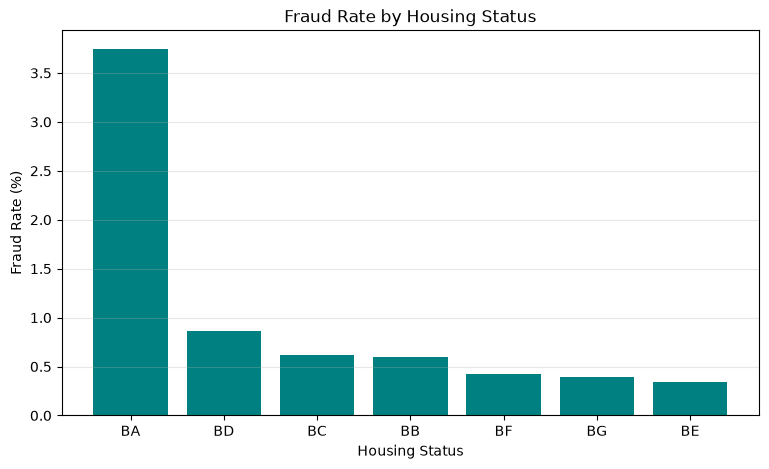

In [38]:
plt.figure(figsize=(9, 5))

plt.bar(
    housing_fraud["housing_status"],
    housing_fraud["fraud_rate_pct"],
    color="teal"
)

plt.title("Fraud Rate by Housing Status")
plt.xlabel("Housing Status")
plt.ylabel("Fraud Rate (%)")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Finding

Housing-status category BA recorded the highest fraud rate at approximately
3.75% and the largest fraud volume, with 6,357 fraudulent applications.
Its result is supported by a large sample of 169,675 applications.

All other major housing categories had fraud rates below 0.87%. Categories
BF and BG contained relatively few applications, so their results should be
interpreted cautiously. Housing-status codes are anonymized and do not
identify actual housing arrangements.

## Fraud Analysis by Application Source

In [39]:
source_fraud = (
    clean_df.groupby("source")["fraud_bool"]
    .agg(
        total_applications="count",
        fraud_cases="sum",
        fraud_rate="mean"
    )
    .reset_index()
)

In [40]:
source_fraud["fraud_rate_pct"] = (
    source_fraud["fraud_rate"] * 100
)

source_fraud = source_fraud.sort_values(
    "fraud_rate_pct",
    ascending=False
)

source_fraud

,source,total_applications,fraud_cases,fraud_rate,fraud_rate_pct
1,TELEAPP,7048,112,0.015891,1.589103
0,INTERNET,992952,10917,0.010994,1.099449


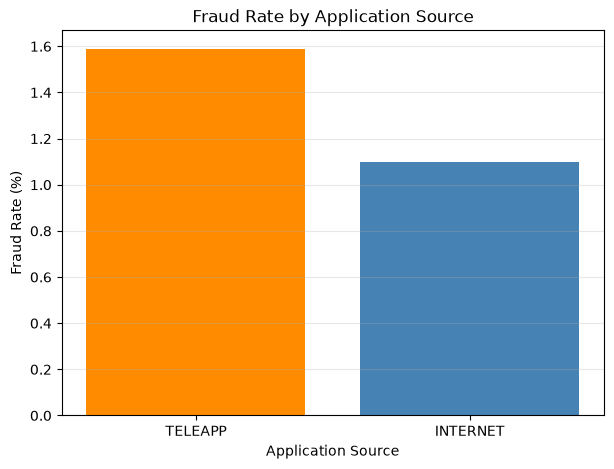

In [41]:
plt.figure(figsize=(7, 5))

plt.bar(
    source_fraud["source"],
    source_fraud["fraud_rate_pct"],
    color=["darkorange", "steelblue"]
)

plt.title("Fraud Rate by Application Source")
plt.xlabel("Application Source")
plt.ylabel("Fraud Rate (%)")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Finding

TELEAPP recorded a fraud rate of approximately 1.59%, compared with 1.10%
for INTERNET. Therefore, the observed fraud rate for TELEAPP was approximately
45% higher.

However, INTERNET generated 10,917 fraud cases because it accounted for
992,952 of the one million applications. TELEAPP generated only 112 cases
from 7,048 applications. This highlights the difference between proportional
risk and total fraud volume.

## Fraud Analysis by Device Operating System

In [42]:
device_fraud = (
    clean_df.groupby("device_os")["fraud_bool"]
    .agg(
        total_applications="count",
        fraud_cases="sum",
        fraud_rate="mean"
    )
    .reset_index()
)

In [43]:
device_fraud["fraud_rate_pct"] = (
    device_fraud["fraud_rate"] * 100
)

In [44]:
device_fraud = device_fraud.sort_values(
    "fraud_rate_pct",
    ascending=False
)

device_fraud

,device_os,total_applications,fraud_cases,fraud_rate,fraud_rate_pct
3,windows,263506,6507,0.024694,2.469393
1,macintosh,53826,752,0.013971,1.397094
4,x11,7228,81,0.011206,1.120642
2,other,342728,1974,0.005760,0.575967
0,linux,332712,1715,0.005155,0.515461


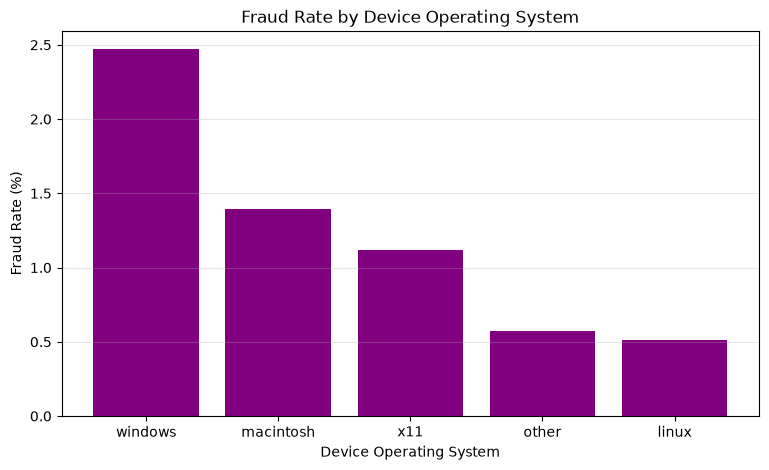

In [45]:
plt.figure(figsize=(9, 5))

plt.bar(
    device_fraud["device_os"],
    device_fraud["fraud_rate_pct"],
    color="purple"
)

plt.title("Fraud Rate by Device Operating System")
plt.xlabel("Device Operating System")
plt.ylabel("Fraud Rate (%)")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Finding

Windows applications recorded the highest fraud rate at approximately 2.47%
and the largest fraud volume, with 6,507 fraudulent applications. Macintosh
followed with a fraud rate of approximately 1.40%.

Linux and other operating systems recorded substantially lower fraud rates
of approximately 0.52% and 0.58%. Although X11 had a rate of approximately
1.12%, it represented only 7,228 applications and should be interpreted with
more caution.

The results indicate an association between device operating system and
fraud risk, but they do not establish that the operating system causes fraud.

## Fraud Analysis by Binary Features

In [46]:
binary_features = ["email_is_free","phone_home_valid","phone_mobile_valid","has_other_cards","foreign_request","keep_alive_session"]

In [47]:
binary_results = []

In [48]:
for feature in binary_features:
    result = (
        clean_df.groupby(feature)["fraud_bool"]
        .agg(
            total_applications="count",
            fraud_cases="sum",
            fraud_rate="mean"
        )
        .reset_index()
    )

    result = result.rename(columns={feature: "value"})
    result.insert(0, "feature", feature)
    result["fraud_rate_pct"] = result["fraud_rate"] * 100

    binary_results.append(result)

In [49]:
binary_fraud = pd.concat(
    binary_results,
    ignore_index=True
)

binary_fraud

,feature,value,total_applications,fraud_cases,fraud_rate,fraud_rate_pct
0,email_is_free,0,470114,3738,0.007951,0.795126
1,email_is_free,1,529886,7291,0.013760,1.375956
2,phone_home_valid,0,582923,8238,0.014132,1.413223
3,phone_home_valid,1,417077,2791,0.006692,0.669181
4,phone_mobile_valid,0,110324,1648,0.014938,1.493782
5,phone_mobile_valid,1,889676,9381,0.010544,1.054429
6,has_other_cards,0,777012,10098,0.012996,1.299594
7,has_other_cards,1,222988,931,0.004175,0.417511
8,foreign_request,0,974758,10474,0.010745,1.074523
9,foreign_request,1,25242,555,0.021987,2.198716


In [50]:
binary_plot = binary_fraud.pivot(
    index="feature",
    columns="value",
    values="fraud_rate_pct"
)

binary_plot

value,0,1
feature,,
email_is_free,0.795126,1.375956
foreign_request,1.074523,2.198716
has_other_cards,1.299594,0.417511
keep_alive_session,1.716333,0.653093
phone_home_valid,1.413223,0.669181
phone_mobile_valid,1.493782,1.054429


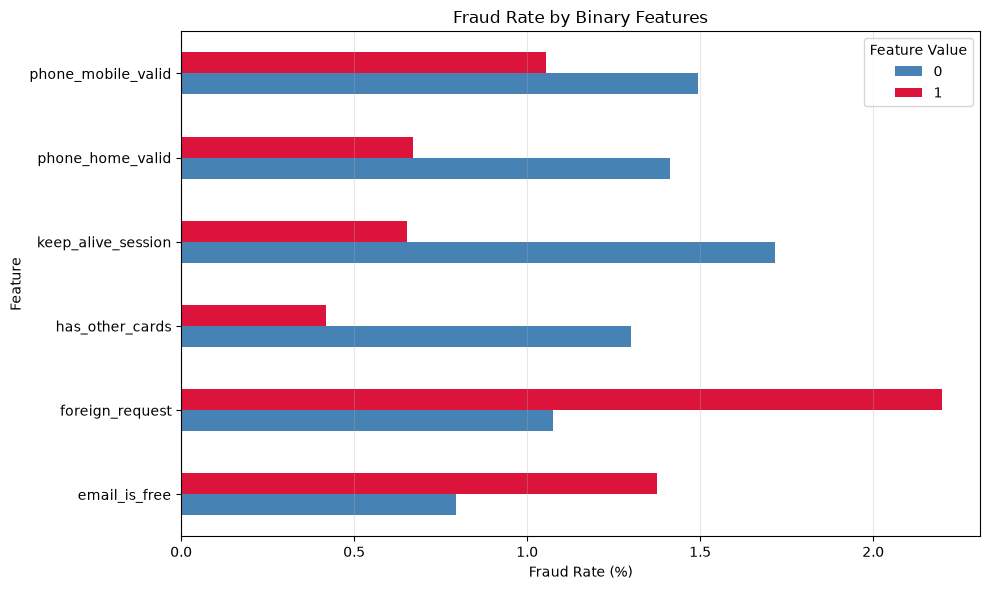

In [51]:
ax = binary_plot.plot(
    kind="barh",
    figsize=(10, 6),
    color=["steelblue", "crimson"]
)

ax.set_title("Fraud Rate by Binary Features")
ax.set_xlabel("Fraud Rate (%)")
ax.set_ylabel("Feature")
ax.legend(title="Feature Value")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Finding

Foreign requests recorded a fraud rate of approximately 2.20%, more than
double the 1.07% rate for non-foreign requests.

Applications without a keep-alive session recorded a fraud rate of 1.72%,
compared with 0.65% when keep-alive was enabled. Applicants without other
cards also had a substantially higher fraud rate of 1.30%, compared with
0.42% for applicants with other cards.

Free email usage and invalid phone information were also associated with
higher observed fraud rates. These variables show useful risk signals, but
the results represent associations and do not prove causation.

## Fraud Analysis by Customer Age

In [52]:
clean_df["customer_age"].value_counts().sort_index()

customer_age
10     20987
20    245855
30    311433
40    238712
50    140353
60     34770
70      6517
80      1297
90        76
Name: count, dtype: int64

In [53]:
age_fraud = (
    clean_df.groupby("customer_age")["fraud_bool"]
    .agg(
        total_applications="count",
        fraud_cases="sum",
        fraud_rate="mean"
    )
    .reset_index()
)

In [54]:
age_fraud["fraud_rate_pct"] = (
    age_fraud["fraud_rate"] * 100
)

age_fraud

,customer_age,total_applications,fraud_cases,fraud_rate,fraud_rate_pct
0,10,20987,74,0.003526,0.352599
1,20,245855,1205,0.004901,0.490126
2,30,311433,2589,0.008313,0.831318
3,40,238712,2876,0.012048,1.204799
4,50,140353,2805,0.019985,1.998532
5,60,34770,1149,0.033046,3.304573
6,70,6517,263,0.040356,4.035599
7,80,1297,64,0.049345,4.934464
8,90,76,4,0.052632,5.263158


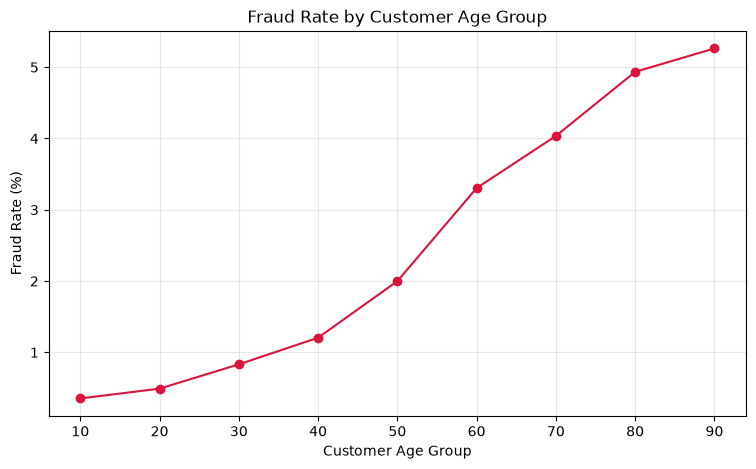

In [55]:
plt.figure(figsize=(9, 5))

plt.plot(
    age_fraud["customer_age"],
    age_fraud["fraud_rate_pct"],
    marker="o",
    color="crimson"
)

plt.title("Fraud Rate by Customer Age Group")
plt.xlabel("Customer Age Group")
plt.ylabel("Fraud Rate (%)")
plt.grid(alpha=0.3)

plt.show()

### Finding

The observed fraud rate increased consistently across customer age groups,
rising from approximately 0.35% for age group 10 to 4.04% for age group 70.

The age-80 and age-90 groups recorded higher rates, but these categories
contained only 1,297 and 76 applications, respectively. Their estimates are
therefore less reliable than those of the larger age groups.

Customer age appears to be strongly associated with fraud risk in this
dataset. However, this relationship does not prove that age causes fraud,
and age should not be used as the sole basis for an account decision.

## Fraud Analysis by Income Level

In [56]:
clean_df["income"].value_counts().sort_index()

income
0.1    157449
0.2     69345
0.3     50833
0.4     81364
0.5     55858
0.6    111973
0.7    105109
0.8    146650
0.9    221419
Name: count, dtype: int64

In [57]:
income_fraud = (
    clean_df.groupby("income")["fraud_bool"]
    .agg(
        total_applications="count",
        fraud_cases="sum",
        fraud_rate="mean"
    )
    .reset_index()
)

In [58]:
income_fraud["fraud_rate_pct"] = (
    income_fraud["fraud_rate"] * 100
)

income_fraud

,income,total_applications,fraud_cases,fraud_rate,fraud_rate_pct
0,0.1,157449,909,0.005773,0.577330
1,0.2,69345,438,0.006316,0.631624
2,0.3,50833,338,0.006649,0.664922
3,0.4,81364,597,0.007337,0.733740
4,0.5,55858,444,0.007949,0.794873
5,0.6,111973,983,0.008779,0.877890
6,0.7,105109,927,0.008819,0.881942
7,0.8,146650,1602,0.010924,1.092397
8,0.9,221419,4791,0.021638,2.163771


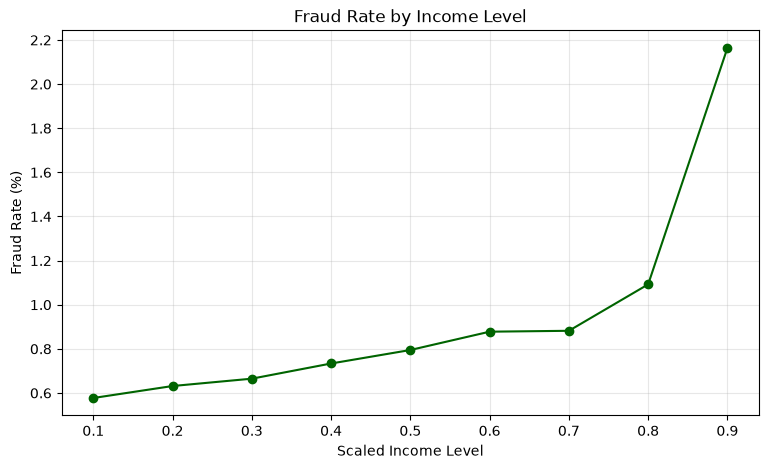

In [59]:
plt.figure(figsize=(9, 5))

plt.plot(
    income_fraud["income"],
    income_fraud["fraud_rate_pct"],
    marker="o",
    color="darkgreen"
)

plt.title("Fraud Rate by Income Level")
plt.xlabel("Scaled Income Level")
plt.ylabel("Fraud Rate (%)")
plt.grid(alpha=0.3)

plt.show()

### Finding

The observed fraud rate generally increased with the scaled income level.
It rose from approximately 0.58% at income level 0.1 to 1.09% at level 0.8,
before increasing sharply to 2.16% at level 0.9.

The highest income category contained 221,419 applications, so its elevated
rate is supported by a substantial sample. However, the income values are
scaled categories and do not represent actual currency amounts.

This association does not establish that income causes fraud. The pattern may
also interact with other variables, including proposed credit limits, age and
application characteristics.

## Fraud Analysis by Proposed Credit Limit

In [60]:
clean_df["proposed_credit_limit"].value_counts().sort_index()

proposed_credit_limit
190.0        163
200.0     613854
210.0        607
490.0        870
500.0     135797
510.0       6967
990.0       7580
1000.0     81882
1500.0    145735
1900.0       390
2000.0      6114
2100.0        41
Name: count, dtype: int64

In [61]:
credit_limit_fraud = (
    clean_df.groupby("proposed_credit_limit")["fraud_bool"]
    .agg(
        total_applications="count",
        fraud_cases="sum",
        fraud_rate="mean"
    )
    .reset_index()
)

In [62]:
credit_limit_fraud["fraud_rate_pct"] = (
    credit_limit_fraud["fraud_rate"] * 100
)

credit_limit_fraud

,proposed_credit_limit,total_applications,fraud_cases,fraud_rate,fraud_rate_pct
0,190.0,163,1,0.006135,0.613497
1,200.0,613854,4424,0.007207,0.720693
2,210.0,607,1,0.001647,0.164745
3,490.0,870,12,0.013793,1.379310
4,500.0,135797,1458,0.010737,1.073661
5,510.0,6967,32,0.004593,0.459308
6,990.0,7580,136,0.017942,1.794195
7,1000.0,81882,904,0.011040,1.104028
8,1500.0,145735,3183,0.021841,2.184101
9,1900.0,390,80,0.205128,20.512821


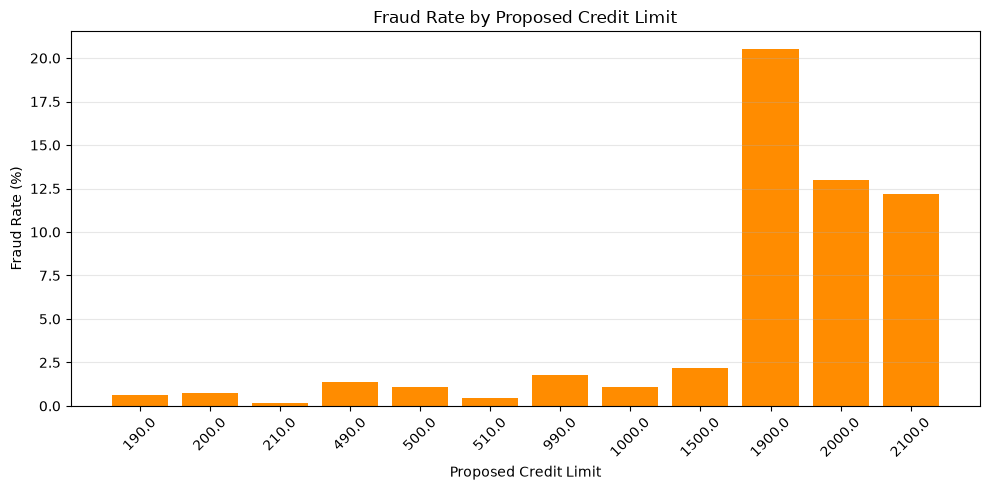

In [63]:
plt.figure(figsize=(10, 5))

plt.bar(
    credit_limit_fraud["proposed_credit_limit"].astype(str),
    credit_limit_fraud["fraud_rate_pct"],
    color="darkorange"
)

plt.title("Fraud Rate by Proposed Credit Limit")
plt.xlabel("Proposed Credit Limit")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### Finding

Fraud rates were generally higher among applications requesting larger credit
limits. The fraud rate increased from approximately 0.72% for the most common
limit of 200 to 2.18% for a limit of 1,500 and 12.97% for a limit of 2,000.

The 1,900 category recorded the highest fraud rate at 20.51%, but it contained
only 390 applications. Similarly, the 2,100 category contained only 41
applications. These results should therefore be interpreted cautiously.

The findings show an association between higher proposed credit limits and
fraud risk, but they do not establish causation.

## Credit Risk Score Analysis

In [64]:
credit_score_summary = (
    clean_df.groupby("fraud_bool")["credit_risk_score"]
    .agg(
        total_applications="count",
        average_score="mean",
        median_score="median",
        standard_deviation="std",
        minimum_score="min",
        maximum_score="max"
    )
    .reset_index()
)

credit_score_summary

,fraud_bool,total_applications,average_score,median_score,standard_deviation,minimum_score,maximum_score
0,0,988971,130.469904,122.0,69.357052,-170,389
1,1,11029,177.590353,178.0,81.910348,-97,378


In [65]:
credit_score_analysis = clean_df[
    ["credit_risk_score", "fraud_bool"]
].copy()

In [66]:
credit_score_analysis["score_group"] = pd.qcut(
    credit_score_analysis["credit_risk_score"],
    q=10,
    duplicates="drop"
)

In [67]:
credit_score_fraud = (
    credit_score_analysis.groupby(
        "score_group",
        observed=True
    )["fraud_bool"]
    .agg(
        total_applications="count",
        fraud_cases="sum",
        fraud_rate="mean"
    )
    .reset_index()
)

credit_score_fraud["fraud_rate_pct"] = (
    credit_score_fraud["fraud_rate"] * 100
)

credit_score_fraud

,score_group,total_applications,fraud_cases,fraud_rate,fraud_rate_pct
0,"(-170.001, 48.0]",101543,553,0.005446,0.544597
1,"(48.0, 73.0]",98852,673,0.006808,0.680816
2,"(73.0, 92.0]",104773,741,0.007072,0.707243
3,"(92.0, 107.0]",96088,609,0.006338,0.633794
4,"(107.0, 122.0]",99356,610,0.006140,0.613954
5,"(122.0, 141.0]",103698,716,0.006905,0.690467
6,"(141.0, 165.0]",98370,1000,0.010166,1.016570
7,"(165.0, 192.0]",100084,1255,0.012539,1.253947
8,"(192.0, 226.0]",98672,1539,0.015597,1.559713
9,"(226.0, 389.0]",98564,3333,0.033816,3.381559


In [68]:
credit_score_fraud["score_group_label"] = (
    credit_score_fraud["score_group"].astype(str)
)

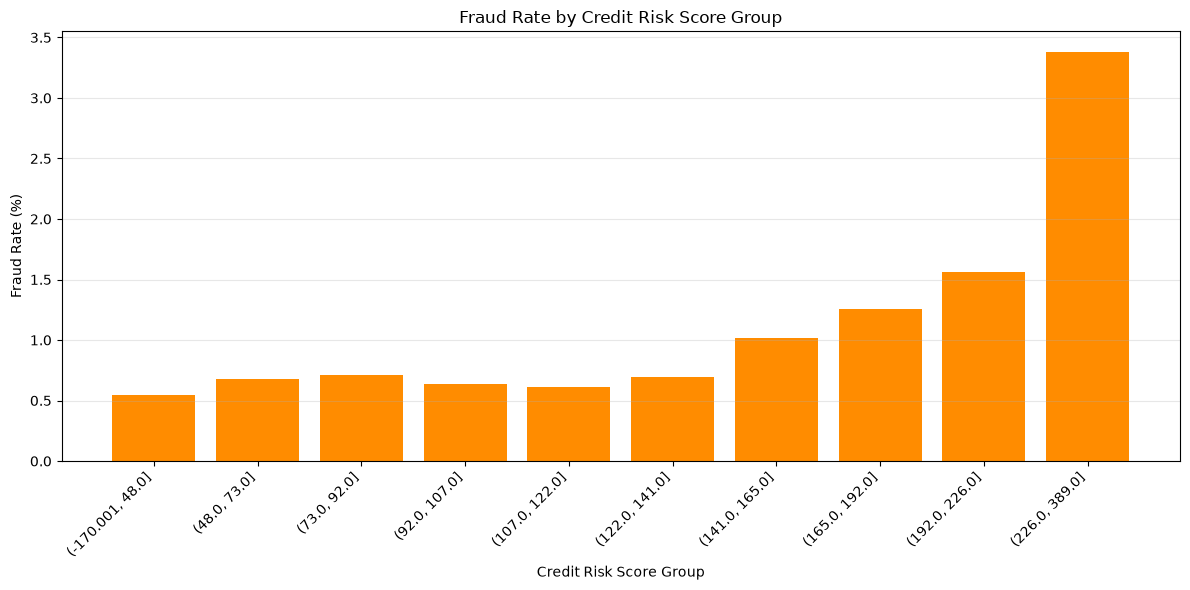

In [69]:
plt.figure(figsize=(12, 6))

plt.bar(
    credit_score_fraud["score_group_label"],
    credit_score_fraud["fraud_rate_pct"],
    color="darkorange"
)

plt.title("Fraud Rate by Credit Risk Score Group")
plt.xlabel("Credit Risk Score Group")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### Finding

Fraud rates remained below approximately 0.71% across score groups below
141. The rate then increased as the credit-risk score rose, reaching 1.56%
for scores between 192 and 226.

The highest score group, from 226 to 389, recorded a fraud rate of
approximately 3.38%. This was around six times the rate recorded by the
lowest score group.

Each group contained approximately 100,000 applications, providing a balanced
comparison. The result indicates that credit-risk score is likely to be an
important predictor in the fraud-detection model.

## Behavioural Feature Analysis

In [70]:
behavioural_features = ["name_email_similarity","days_since_request","intended_balcon_amount","zip_count_4w","velocity_6h","velocity_24h","velocity_4w","bank_branch_count_8w","date_of_birth_distinct_emails_4w","prev_address_months_count","current_address_months_count","bank_months_count","session_length_in_minutes","device_distinct_emails_8w"]

In [71]:
behavioural_summary = (clean_df.groupby("fraud_bool")[behavioural_features].median().T.reset_index())

In [72]:
behavioural_summary.columns = [
    "feature",
    "legitimate_median",
    "fraud_median"
]

behavioural_summary

,feature,legitimate_median,fraud_median
0,name_email_similarity,0.493571,0.292420
1,days_since_request,0.015203,0.013094
2,intended_balcon_amount,-0.829552,-0.900578
3,zip_count_4w,1262.000000,1328.000000
4,velocity_6h,5324.540439,4916.464728
5,velocity_24h,4751.027067,4665.725851
6,velocity_4w,4914.578888,4827.695220
7,bank_branch_count_8w,9.000000,2.000000
8,date_of_birth_distinct_emails_4w,9.000000,7.000000
9,prev_address_months_count,34.000000,53.000000


### Name–Email Similarity

In [73]:
similarity_analysis = clean_df[["name_email_similarity", "fraud_bool"]].copy()

In [74]:
similarity_analysis["similarity_group"] = pd.qcut(
    similarity_analysis["name_email_similarity"],
    q=10,
    duplicates="drop"
)

In [75]:
similarity_fraud = (
    similarity_analysis.groupby(
        "similarity_group",
        observed=True
    )["fraud_bool"]
    .agg(
        total_applications="count",
        fraud_cases="sum",
        fraud_rate="mean"
    )
    .reset_index()
)

similarity_fraud["fraud_rate_pct"] = (
    similarity_fraud["fraud_rate"] * 100
)

similarity_fraud

,similarity_group,total_applications,fraud_cases,fraud_rate,fraud_rate_pct
0,"(-0.00099857, 0.107]",100000,2050,0.02050,2.050
1,"(0.107, 0.183]",100000,1862,0.01862,1.862
2,"(0.183, 0.272]",100000,1350,0.01350,1.350
3,"(0.272, 0.39]",100000,1089,0.01089,1.089
4,"(0.39, 0.492]",100000,708,0.00708,0.708
5,"(0.492, 0.588]",100000,695,0.00695,0.695
6,"(0.588, 0.707]",100000,753,0.00753,0.753
7,"(0.707, 0.806]",100000,999,0.00999,0.999
8,"(0.806, 0.883]",100000,835,0.00835,0.835
9,"(0.883, 1.0]",100000,688,0.00688,0.688


In [76]:
similarity_fraud["similarity_group_label"] = (similarity_fraud["similarity_group"].astype(str))

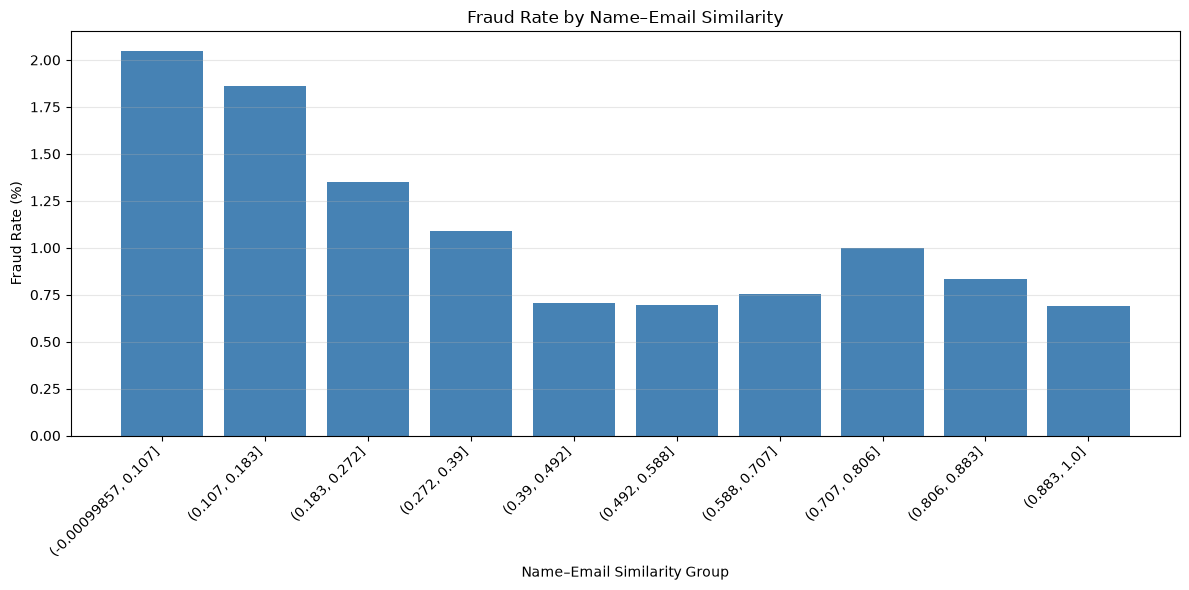

In [77]:
plt.figure(figsize=(12, 6))

plt.bar(
    similarity_fraud["similarity_group_label"],
    similarity_fraud["fraud_rate_pct"],
    color="steelblue"
)

plt.title("Fraud Rate by Name–Email Similarity")
plt.xlabel("Name–Email Similarity Group")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### Finding

Applications in the lowest name–email similarity group recorded a fraud rate
of approximately 2.05%, compared with 0.69% in the highest similarity group.
This means that the lowest-similarity group had almost three times the observed
fraud rate of the highest-similarity group.

Although the fraud rate did not decrease perfectly across every interval, the
overall results suggest that low similarity between an applicant's name and
email address is a meaningful fraud-risk signal. Each group contained 100,000
applications, making the comparison well balanced.

## Missing Information and Fraud Risk

In [78]:
missingness_results = []

In [79]:
for column in missing_columns:
    temporary_data = clean_df[
        [column, "fraud_bool"]
    ].copy()

    temporary_data["is_missing"] = (
        temporary_data[column]
        .isna()
        .astype(int)
    )

    result = (
        temporary_data.groupby("is_missing")["fraud_bool"]
        .agg(
            total_applications="count",
            fraud_cases="sum",
            fraud_rate="mean"
        )
        .reset_index()
    )

    result.insert(0, "feature", column)
    result["fraud_rate_pct"] = result["fraud_rate"] * 100

    missingness_results.append(result)

In [80]:
missingness_fraud = pd.concat(
    missingness_results,
    ignore_index=True
)

missingness_fraud

,feature,is_missing,total_applications,fraud_cases,fraud_rate,fraud_rate_pct
0,prev_address_months_count,0,287080,895,0.003118,0.311760
1,prev_address_months_count,1,712920,10134,0.014215,1.421478
2,current_address_months_count,0,995746,11015,0.011062,1.106206
3,current_address_months_count,1,4254,14,0.003291,0.329102
4,bank_months_count,0,746365,6889,0.009230,0.923007
5,bank_months_count,1,253635,4140,0.016323,1.632267
6,session_length_in_minutes,0,997985,11011,0.011033,1.103323
7,session_length_in_minutes,1,2015,18,0.008933,0.893300
8,device_distinct_emails_8w,0,999641,11025,0.011029,1.102896
9,device_distinct_emails_8w,1,359,4,0.011142,1.114206


In [81]:
missingness_plot = missingness_fraud.pivot(
    index="feature",
    columns="is_missing",
    values="fraud_rate_pct"
)

missingness_plot

is_missing,0,1
feature,,
bank_months_count,0.923007,1.632267
current_address_months_count,1.106206,0.329102
device_distinct_emails_8w,1.102896,1.114206
prev_address_months_count,0.311760,1.421478
session_length_in_minutes,1.103323,0.893300


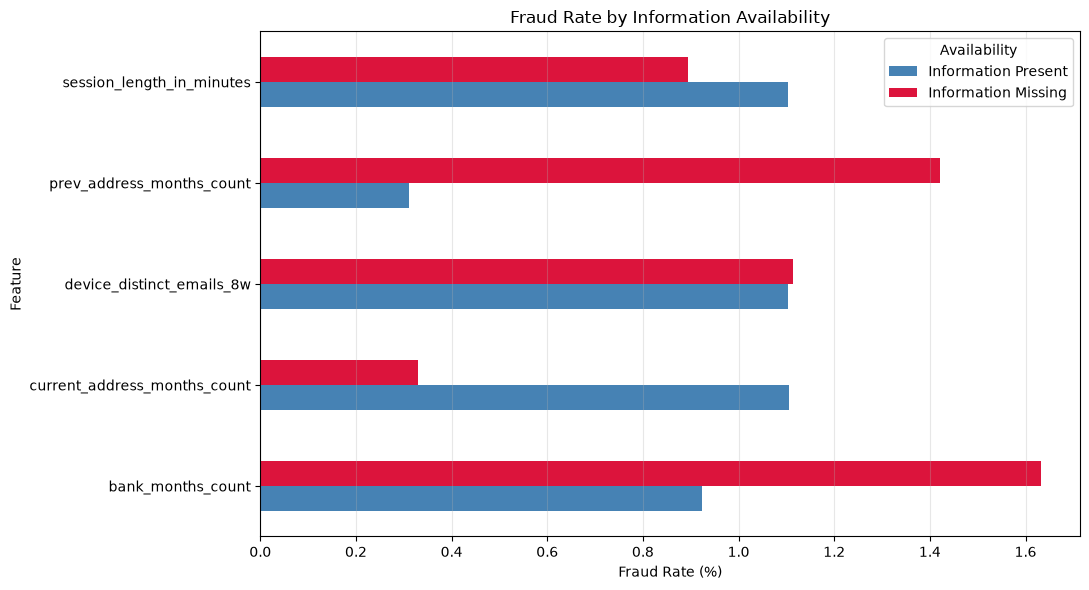

In [82]:
ax = missingness_plot.plot(
    kind="barh",
    figsize=(11, 6),
    color=["steelblue", "crimson"]
)

ax.set_title("Fraud Rate by Information Availability")
ax.set_xlabel("Fraud Rate (%)")
ax.set_ylabel("Feature")
ax.legend(
    ["Information Present", "Information Missing"],
    title="Availability"
)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Finding

Applications with missing previous-address information recorded a fraud rate
of approximately 1.42%, compared with 0.31% when that information was
available. Missing bank-history duration was also associated with a higher
fraud rate of 1.63%, compared with 0.92% when present.

Missingness did not increase fraud risk consistently across every feature.
Missing current-address and session-length information had lower observed
rates, while missing device-email information showed almost no difference.

This suggests that missing-value indicators may be useful model features,
particularly for previous-address and banking-history information. Missing
values should therefore be imputed rather than deleting the associated rows,
while also preserving indicators that identify which values were unavailable.

## Numerical Feature Correlation with Fraud

In [83]:
fraud_correlations = (
    clean_df.select_dtypes(include="number")
    .corr()["fraud_bool"]
    .drop("fraud_bool")
    .sort_values(
        key=abs,
        ascending=False
    )
)

fraud_correlations

credit_risk_score                   0.070624
proposed_credit_limit               0.068907
customer_age                        0.062959
keep_alive_session                 -0.050296
income                              0.045079
date_of_birth_distinct_emails_4w   -0.043224
name_email_similarity              -0.036720
device_distinct_emails_8w           0.036542
has_other_cards                    -0.035156
phone_home_valid                   -0.035128
current_address_months_count        0.033480
email_is_free                       0.027758
intended_balcon_amount             -0.024524
bank_months_count                   0.020929
prev_address_months_count           0.020083
velocity_6h                        -0.016892
foreign_request                     0.016885
month                               0.013250
phone_mobile_valid                 -0.013180
bank_branch_count_8w               -0.011577
velocity_4w                        -0.011536
velocity_24h                       -0.011183
session_le

In [84]:
top_correlations = (
    fraud_correlations
    .head(12)
    .sort_values()
)

top_correlations

keep_alive_session                 -0.050296
date_of_birth_distinct_emails_4w   -0.043224
name_email_similarity              -0.036720
has_other_cards                    -0.035156
phone_home_valid                   -0.035128
email_is_free                       0.027758
current_address_months_count        0.033480
device_distinct_emails_8w           0.036542
income                              0.045079
customer_age                        0.062959
proposed_credit_limit               0.068907
credit_risk_score                   0.070624
Name: fraud_bool, dtype: float64

In [85]:
correlation_colors = [
    "crimson" if value > 0 else "steelblue"
    for value in top_correlations.values
]

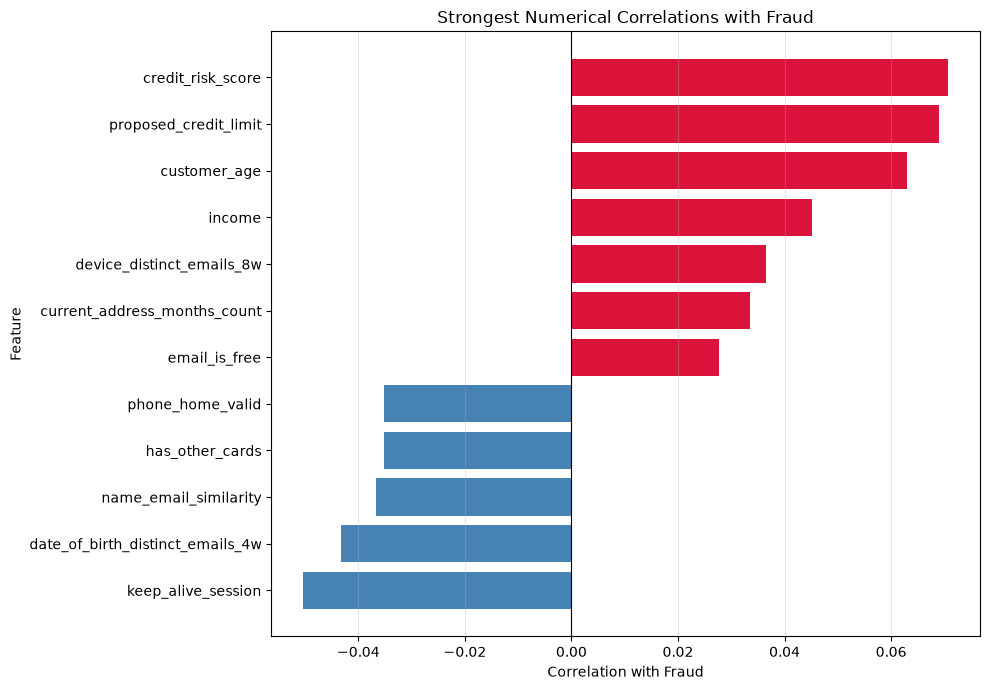

In [86]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_correlations.index,
    top_correlations.values,
    color=correlation_colors
)

plt.axvline(
    0,
    color="black",
    linewidth=0.8
)

plt.title("Strongest Numerical Correlations with Fraud")
plt.xlabel("Correlation with Fraud")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

### Finding

Credit-risk score, proposed credit limit and customer age had the strongest
positive numerical correlations with fraud. Keep-alive session,
date-of-birth email consistency and name–email similarity had the strongest
negative correlations.

All individual correlations were relatively weak, with absolute values below
0.08. This indicates that fraud is unlikely to be explained by one numerical
feature alone. A machine-learning model may still identify useful nonlinear
patterns and interactions between multiple features.

Correlation represents association and does not establish causation.

# Conclusions and Business Recommendations

## Project Overview

This analysis examined 1,000,000 anonymized bank-account applications to
identify characteristics associated with application fraud. The dataset
contained 11,029 fraudulent applications, representing approximately 1.10%
of all records.

## Key Findings

1. **Fraud is highly imbalanced:** Only 1.10% of applications were fraudulent.
   Therefore, accuracy alone would be inappropriate for evaluating a future
   fraud-detection model.

2. **Fraud increased over time:** The fraud rate fell to approximately 0.87%
   in period 2 before increasing to 1.47% in period 7. This suggests that
   fraud patterns may change over time.

3. **Important categorical risk signals:** Payment type AC, employment
   category CC, housing category BA and Windows devices recorded notably
   higher fraud rates than their comparison groups.

4. **Application source showed different risks:** TELEAPP recorded a fraud
   rate of 1.59%, compared with 1.10% for INTERNET. However, INTERNET
   generated almost all fraud volume because it represented most applications.

5. **Binary indicators provided useful signals:** Foreign requests, missing
   keep-alive sessions, free email usage, invalid phone information and the
   absence of other cards were associated with higher fraud rates.

6. **Fraud increased across age and income groups:** Older age groups and
   higher scaled-income categories recorded higher observed fraud rates.
   These relationships require fairness and compliance assessment and should
   not be used alone to make account decisions.

7. **Credit-related features were important:** Higher credit-risk scores and
   proposed credit limits were associated with increased fraud. Applications
   proposing a credit limit of 2,000 recorded a fraud rate of approximately
   12.97%.

8. **Identity consistency was informative:** The lowest name–email similarity
   group recorded a 2.05% fraud rate, compared with 0.69% in the highest
   similarity group.

9. **Missing information can be predictive:** Missing previous-address and
   banking-history information was associated with elevated fraud rates.
   Missing-value indicators should be preserved during model development.

10. **No single numerical feature explains fraud:** All individual numerical
    correlations had absolute values below 0.08. Fraud is therefore likely
    influenced by nonlinear relationships and interactions among multiple
    features.

## Business Recommendations

- Apply enhanced verification to applications containing several high-risk
  signals instead of rejecting applications based on one characteristic.
- Prioritize investigation of high credit limits, elevated credit-risk scores,
  foreign requests and low name–email similarity.
- Maintain separate monitoring for proportional risk and total fraud volume.
- Monitor monthly fraud rates for changes in fraud behaviour and model drift.
- Preserve missing-value indicators during machine-learning preprocessing.
- Evaluate the future model using precision, recall, F1-score and PR-AUC
  rather than accuracy alone.
- Conduct fairness assessments before using age, income, employment or housing
  information in production decisions.
- Use model predictions to support human review rather than as the sole basis
  for automatic rejection.

## Limitations

The dataset is anonymized and synthetically generated from patterns in a
real-world fraud dataset. Category codes do not reveal their original
business meanings. The findings represent statistical associations and do
not prove causation. Results from rare categories should also be interpreted
cautiously because their fraud rates are based on small samples.